# 02 — LOSO Split Builder (Fixed for Dataset V2)

This notebook builds the official **Leave-One-Subject-Out (LOSO)** split files for the KM thermal cold-region segmentation project.

Input from previous notebook:

```text
dataset_v2_prepared/
├── manifest_v2.csv
└── training_manifest_v2.csv
```

Output:

```text
dataset_v2_splits/
├── fold_S05.json
├── fold_S06.json
├── ...
├── loso_split_summary.csv
├── loso_all_folds_manifest.csv
├── subject_distribution.csv
└── cold_distribution_by_subject.csv
```

In [1]:
from pathlib import Path
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Ready.")

Ready.


In [2]:
# ============================================================
# SECTION 01 — LOCATE DATASET V2 OUTPUTS
# ============================================================

PREP_DIR = None

# Example manual path:
# PREP_DIR = Path("/media/data/rPPG/rPPG_Data/SHARE/PixelLabelData/dataset_v2_prepared")

target_manifest_name = "training_manifest_v2.csv"

if PREP_DIR is None:
    search_roots = [
        Path.cwd(),
        Path("/media/data/rPPG/rPPG_Data/SHARE/PixelLabelData"),
        Path("/mnt/data"),
    ]

    found = []
    for root in search_roots:
        if root.exists():
            found.extend(list(root.rglob(target_manifest_name)))

    if len(found) == 0:
        raise FileNotFoundError(
            "Could not find training_manifest_v2.csv. "
            "Set PREP_DIR manually to your dataset_v2_prepared folder."
        )

    found = sorted(set(found), key=lambda p: (len(str(p)), str(p)))
    TRAIN_MANIFEST_PATH = found[0]
    PREP_DIR = TRAIN_MANIFEST_PATH.parent
else:
    PREP_DIR = Path(PREP_DIR)
    TRAIN_MANIFEST_PATH = PREP_DIR / target_manifest_name

FULL_MANIFEST_PATH = PREP_DIR / "manifest_v2.csv"

if not TRAIN_MANIFEST_PATH.exists():
    raise FileNotFoundError(TRAIN_MANIFEST_PATH)

print("PREP_DIR:", PREP_DIR)
print("TRAIN_MANIFEST_PATH:", TRAIN_MANIFEST_PATH)
print("FULL_MANIFEST_PATH:", FULL_MANIFEST_PATH if FULL_MANIFEST_PATH.exists() else "not found")

PREP_DIR: /media/data/rPPG/rPPG_Data/SHARE/PixelLabelData/dataset_v2_prepared
TRAIN_MANIFEST_PATH: /media/data/rPPG/rPPG_Data/SHARE/PixelLabelData/dataset_v2_prepared/training_manifest_v2.csv
FULL_MANIFEST_PATH: /media/data/rPPG/rPPG_Data/SHARE/PixelLabelData/dataset_v2_prepared/manifest_v2.csv


In [3]:
# ============================================================
# SECTION 02 — LOAD TRAINING MANIFEST
# ============================================================

df = pd.read_csv(TRAIN_MANIFEST_PATH)

print("Loaded training manifest:", df.shape)
display(df.head())

# This notebook accepts the Dataset V2 column names from 01_Dataset_V2_PREP.ipynb.
# The training manifest may contain prepared_image_npy/prepared_image_png instead of image_path.
if "image_path" not in df.columns:
    if "prepared_image_npy" in df.columns:
        df["image_path"] = df["prepared_image_npy"]
        print("Created image_path from prepared_image_npy")
    elif "prepared_image_png" in df.columns:
        df["image_path"] = df["prepared_image_png"]
        print("Created image_path from prepared_image_png")
    else:
        raise ValueError(
            "Missing image path column. Expected one of: image_path, prepared_image_npy, prepared_image_png"
        )

required_cols = ["subject_id", "image_path", "body_mask_path", "cold_mask_path"]
missing = [c for c in required_cols if c not in df.columns]

if missing:
    raise ValueError(f"Missing required columns in training_manifest_v2.csv: {missing}")

df["subject_id"] = df["subject_id"].astype(str)

if "doctor_group" not in df.columns:
    df["doctor_group"] = "UNK"
else:
    df["doctor_group"] = df["doctor_group"].astype(str)

if "repeat_id" not in df.columns:
    df["repeat_id"] = -1
else:
    df["repeat_id"] = df["repeat_id"].apply(lambda x: int(float(x)) if str(x).replace(".", "", 1).isdigit() else -1)

if "sample_id" not in df.columns:
    df["sample_id"] = df["subject_id"].astype(str) + "-" + df["doctor_group"].astype(str) + "-" + df["repeat_id"].astype(str)

# Keep only usable rows if the column exists.
if "use_for_training" in df.columns:
    before = len(df)
    df = df[df["use_for_training"].astype(str).str.lower().isin(["true", "1", "yes"])].copy()
    print(f"Filtered use_for_training rows: {len(df)} / {before}")

# Verify paths exist, but do not crash immediately; save a clear table first.
path_check_cols = ["image_path", "body_mask_path", "cold_mask_path"]
for col in path_check_cols:
    df[f"{col}_exists"] = df[col].apply(lambda p: Path(str(p)).exists())

missing_paths = df[~df[[f"{c}_exists" for c in path_check_cols]].all(axis=1)].copy()
if len(missing_paths) > 0:
    missing_path_table = PREP_DIR / "missing_paths_for_loso_split.csv"
    missing_paths.to_csv(missing_path_table, index=False)
    raise FileNotFoundError(
        f"Some files listed in training_manifest_v2.csv do not exist. Saved details to: {missing_path_table}"
    )

# Drop helper path-existence columns before writing JSON.
df = df.drop(columns=[f"{c}_exists" for c in path_check_cols])

display(df[["sample_id", "subject_id", "doctor_group", "repeat_id", "image_path", "body_mask_path", "cold_mask_path"]].head())
print("Ready for LOSO splitting. Usable samples:", len(df))


Loaded training manifest: (78, 11)


,sample_id,subject_id,doctor_group,repeat_id,prepared_image_npy,body_mask_path,cold_mask_path,body_pixels,cold_pixels,cold_body_ratio,use_for_training
0,S05-B-2,S05,B,2,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,29231,4079,0.139544,True
1,S05-B-3,S05,B,3,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,29027,2324,0.080063,True
2,S05-C-1,S05,C,1,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,29324,871,0.029703,True
3,S05-C-2,S05,C,2,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,28034,554,0.019762,True
4,S05-C-3,S05,C,3,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,29153,608,0.020855,True


Created image_path from prepared_image_npy
Filtered use_for_training rows: 78 / 78


,sample_id,subject_id,doctor_group,repeat_id,image_path,body_mask_path,cold_mask_path
0,S05-B-2,S05,B,2,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...
1,S05-B-3,S05,B,3,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...
2,S05-C-1,S05,C,1,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...
3,S05-C-2,S05,C,2,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...
4,S05-C-3,S05,C,3,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...


Ready for LOSO splitting. Usable samples: 78


In [4]:
# ============================================================
# SECTION 03 — NATURAL SORT HELPERS
# ============================================================

def natural_sort_string(x):
    x = str(x)
    parts = re.split(r"(\d+)", x)
    out = []
    for p in parts:
        if p.isdigit():
            out.append(p.zfill(8))
        else:
            out.append(p.lower())
    return "_".join(out)

def natural_sorted(values):
    return sorted(list(values), key=natural_sort_string)

subjects = natural_sorted(df["subject_id"].unique())

print("Subjects:", subjects)
print("Number of subjects:", len(subjects))

if len(subjects) < 3:
    raise ValueError("Need at least 3 subjects for train/val/test LOSO splitting.")

Subjects: ['S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11']
Number of subjects: 7


In [5]:
# ============================================================
# SECTION 04 — DATASET DISTRIBUTION TABLES
# ============================================================

SPLIT_DIR = PREP_DIR.parent / "dataset_v2_splits"
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

dist_rows = []

for sid in subjects:
    g = df[df["subject_id"] == sid]
    row = {
        "subject_id": sid,
        "n_samples": len(g),
        "doctor_groups": ",".join(natural_sorted(g["doctor_group"].dropna().unique())),
        "n_doctor_groups": g["doctor_group"].nunique(dropna=True),
        "repeat_ids": ",".join(map(str, natural_sorted(g["repeat_id"].dropna().unique()))),
        "n_repeat_ids": g["repeat_id"].nunique(dropna=True),
    }

    if "body_pixels" in g.columns:
        row["mean_body_pixels"] = float(g["body_pixels"].mean())
        row["median_body_pixels"] = float(g["body_pixels"].median())

    if "cold_pixels" in g.columns:
        row["mean_cold_pixels"] = float(g["cold_pixels"].mean())
        row["median_cold_pixels"] = float(g["cold_pixels"].median())
        row["min_cold_pixels"] = float(g["cold_pixels"].min())
        row["max_cold_pixels"] = float(g["cold_pixels"].max())

    dist_rows.append(row)

subject_distribution = pd.DataFrame(dist_rows)
subject_distribution.to_csv(SPLIT_DIR / "subject_distribution.csv", index=False)

display(subject_distribution)
print("Saved:", SPLIT_DIR / "subject_distribution.csv")

,subject_id,n_samples,doctor_groups,n_doctor_groups,repeat_ids,n_repeat_ids,mean_body_pixels,median_body_pixels,mean_cold_pixels,median_cold_pixels,min_cold_pixels,max_cold_pixels
0,S05,8,"B,C,D",3,"1,2,3",3,29463.750000,29277.5,1323.375000,739.5,304.0,4079.0
1,S06,11,"A,B,C,D",4,"1,2,3",3,15443.090909,15501.0,1402.363636,490.0,193.0,9837.0
2,S07,12,"A,B,C,D",4,"1,2,3",3,16550.083333,15246.5,1560.916667,964.5,103.0,6765.0
3,S08,11,"A,B,C,D",4,"1,2,3",3,17539.636364,17165.0,454.727273,488.0,57.0,946.0
4,S09,12,"A,B,C,D",4,"1,2,3",3,13150.416667,14550.5,333.750000,248.0,54.0,717.0
5,S10,12,"A,B,C,D",4,"1,2,3",3,9318.916667,9534.5,260.083333,170.5,41.0,724.0
6,S11,12,"A,B,C,D",4,"1,2,3",3,13192.000000,13263.0,2032.000000,1354.0,501.0,4532.0


Saved: /media/data/rPPG/rPPG_Data/SHARE/PixelLabelData/dataset_v2_splits/subject_distribution.csv


In [6]:
# ============================================================
# SECTION 05 — BUILD CYCLIC LOSO PLAN
# ============================================================

fold_plan_rows = []
n = len(subjects)

for i, test_subject in enumerate(subjects):
    val_subject = subjects[(i + 1) % n]
    train_subjects = [s for s in subjects if s not in [test_subject, val_subject]]

    fold_plan_rows.append({
        "fold_id": f"fold_{test_subject}",
        "test_subject": test_subject,
        "val_subject": val_subject,
        "train_subjects": ",".join(train_subjects),
        "n_train_subjects": len(train_subjects),
    })

fold_plan = pd.DataFrame(fold_plan_rows)
display(fold_plan)

,fold_id,test_subject,val_subject,train_subjects,n_train_subjects
0,fold_S05,S05,S06,"S07,S08,S09,S10,S11",5
1,fold_S06,S06,S07,"S05,S08,S09,S10,S11",5
2,fold_S07,S07,S08,"S05,S06,S09,S10,S11",5
3,fold_S08,S08,S09,"S05,S06,S07,S10,S11",5
4,fold_S09,S09,S10,"S05,S06,S07,S08,S11",5
5,fold_S10,S10,S11,"S05,S06,S07,S08,S09",5
6,fold_S11,S11,S05,"S06,S07,S08,S09,S10",5


In [7]:
# ============================================================
# SECTION 06 — BUILD AND SAVE LOSO FOLD JSON FILES
# ============================================================

def clean_value(v):
    if isinstance(v, np.integer):
        return int(v)
    if isinstance(v, np.floating):
        return float(v)
    if pd.isna(v):
        return None
    return v

def dataframe_records(g):
    records = []
    for _, row in g.iterrows():
        records.append({k: clean_value(v) for k, v in row.to_dict().items()})
    return records

summary_rows = []
all_fold_rows = []

for _, plan in fold_plan.iterrows():
    fold_id = plan["fold_id"]
    test_subject = plan["test_subject"]
    val_subject = plan["val_subject"]
    train_subjects = plan["train_subjects"].split(",")

    train_df = df[df["subject_id"].isin(train_subjects)].copy()
    val_df = df[df["subject_id"] == val_subject].copy()
    test_df = df[df["subject_id"] == test_subject].copy()

    assert set(train_df["subject_id"]).isdisjoint(set(val_df["subject_id"]))
    assert set(train_df["subject_id"]).isdisjoint(set(test_df["subject_id"]))
    assert set(val_df["subject_id"]).isdisjoint(set(test_df["subject_id"]))

    fold_payload = {
        "fold_id": fold_id,
        "random_seed": RANDOM_SEED,
        "train_subjects": train_subjects,
        "val_subject": val_subject,
        "test_subject": test_subject,
        "n_train": int(len(train_df)),
        "n_val": int(len(val_df)),
        "n_test": int(len(test_df)),
        "train": dataframe_records(train_df),
        "val": dataframe_records(val_df),
        "test": dataframe_records(test_df),
        "notes": [
            "LOSO split generated from training_manifest_v2.csv.",
            "No test subject appears in train or validation.",
            "No validation subject appears in train.",
            "GenAI augmentation must be trained/generated using train records only for this fold."
        ]
    }

    json_path = SPLIT_DIR / f"{fold_id}.json"
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(fold_payload, f, indent=2)

    summary_rows.append({
        "fold_id": fold_id,
        "train_subjects": ",".join(train_subjects),
        "val_subject": val_subject,
        "test_subject": test_subject,
        "n_train": len(train_df),
        "n_val": len(val_df),
        "n_test": len(test_df),
        "json_path": str(json_path),
    })

    for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
        tmp = split_df.copy()
        tmp["fold_id"] = fold_id
        tmp["split"] = split_name
        tmp["test_subject"] = test_subject
        tmp["val_subject"] = val_subject
        all_fold_rows.append(tmp)

loso_split_summary = pd.DataFrame(summary_rows)
loso_all_folds_manifest = pd.concat(all_fold_rows, ignore_index=True)

loso_split_summary.to_csv(SPLIT_DIR / "loso_split_summary.csv", index=False)
loso_all_folds_manifest.to_csv(SPLIT_DIR / "loso_all_folds_manifest.csv", index=False)

display(loso_split_summary)

print("Saved split directory:", SPLIT_DIR)
print("Saved:", SPLIT_DIR / "loso_split_summary.csv")
print("Saved:", SPLIT_DIR / "loso_all_folds_manifest.csv")

,fold_id,train_subjects,val_subject,test_subject,n_train,n_val,n_test,json_path
0,fold_S05,"S07,S08,S09,S10,S11",S06,S05,59,11,8,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...
1,fold_S06,"S05,S08,S09,S10,S11",S07,S06,55,12,11,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...
2,fold_S07,"S05,S06,S09,S10,S11",S08,S07,55,11,12,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...
3,fold_S08,"S05,S06,S07,S10,S11",S09,S08,55,12,11,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...
4,fold_S09,"S05,S06,S07,S08,S11",S10,S09,54,12,12,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...
5,fold_S10,"S05,S06,S07,S08,S09",S11,S10,54,12,12,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...
6,fold_S11,"S06,S07,S08,S09,S10",S05,S11,58,8,12,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...


Saved split directory: /media/data/rPPG/rPPG_Data/SHARE/PixelLabelData/dataset_v2_splits
Saved: /media/data/rPPG/rPPG_Data/SHARE/PixelLabelData/dataset_v2_splits/loso_split_summary.csv
Saved: /media/data/rPPG/rPPG_Data/SHARE/PixelLabelData/dataset_v2_splits/loso_all_folds_manifest.csv


In [8]:
# ============================================================
# SECTION 07 — SPLIT QUALITY CHECKS
# ============================================================

errors = []

for _, row in loso_split_summary.iterrows():
    fold_id = row["fold_id"]

    fold_rows = loso_all_folds_manifest[loso_all_folds_manifest["fold_id"] == fold_id]
    train_s = set(fold_rows[fold_rows["split"] == "train"]["subject_id"].unique())
    val_s = set(fold_rows[fold_rows["split"] == "val"]["subject_id"].unique())
    test_s = set(fold_rows[fold_rows["split"] == "test"]["subject_id"].unique())

    if not train_s.isdisjoint(val_s):
        errors.append((fold_id, "train-val leakage", train_s & val_s))
    if not train_s.isdisjoint(test_s):
        errors.append((fold_id, "train-test leakage", train_s & test_s))
    if not val_s.isdisjoint(test_s):
        errors.append((fold_id, "val-test leakage", val_s & test_s))

    if len(test_s) != 1:
        errors.append((fold_id, "test does not contain exactly one subject", test_s))
    if len(val_s) != 1:
        errors.append((fold_id, "val does not contain exactly one subject", val_s))

if len(errors) > 0:
    print("ERRORS FOUND:")
    for e in errors:
        print(e)
    raise RuntimeError("Split quality check failed.")

print("All LOSO split leakage checks passed.")

All LOSO split leakage checks passed.


In [9]:
# ============================================================
# SECTION 08 — COLD DISTRIBUTION BY SUBJECT
# ============================================================

if "cold_pixels" in df.columns and "body_pixels" in df.columns:
    cold_distribution_by_subject = (
        df.groupby("subject_id")
        .agg(
            n_samples=("subject_id", "size"),
            mean_body_pixels=("body_pixels", "mean"),
            std_body_pixels=("body_pixels", "std"),
            mean_cold_pixels=("cold_pixels", "mean"),
            std_cold_pixels=("cold_pixels", "std"),
            median_cold_pixels=("cold_pixels", "median"),
            min_cold_pixels=("cold_pixels", "min"),
            max_cold_pixels=("cold_pixels", "max"),
        )
        .reset_index()
    )

    cold_distribution_by_subject.to_csv(SPLIT_DIR / "cold_distribution_by_subject.csv", index=False)

    display(cold_distribution_by_subject)
    print("Saved:", SPLIT_DIR / "cold_distribution_by_subject.csv")
else:
    print("cold_pixels/body_pixels columns are missing. Skipping cold distribution table.")

,subject_id,n_samples,mean_body_pixels,std_body_pixels,mean_cold_pixels,std_cold_pixels,median_cold_pixels,min_cold_pixels,max_cold_pixels
0,S05,8,29463.750000,891.537316,1323.375000,1282.561493,739.5,304,4079
1,S06,11,15443.090909,416.492126,1402.363636,2808.982530,490.0,193,9837
2,S07,12,16550.083333,2911.537534,1560.916667,1869.095234,964.5,103,6765
3,S08,11,17539.636364,1840.369978,454.727273,314.680820,488.0,57,946
4,S09,12,13150.416667,2980.269495,333.750000,217.817741,248.0,54,717
5,S10,12,9318.916667,856.109536,260.083333,217.361642,170.5,41,724
6,S11,12,13192.000000,659.933330,2032.000000,1542.474576,1354.0,501,4532


Saved: /media/data/rPPG/rPPG_Data/SHARE/PixelLabelData/dataset_v2_splits/cold_distribution_by_subject.csv


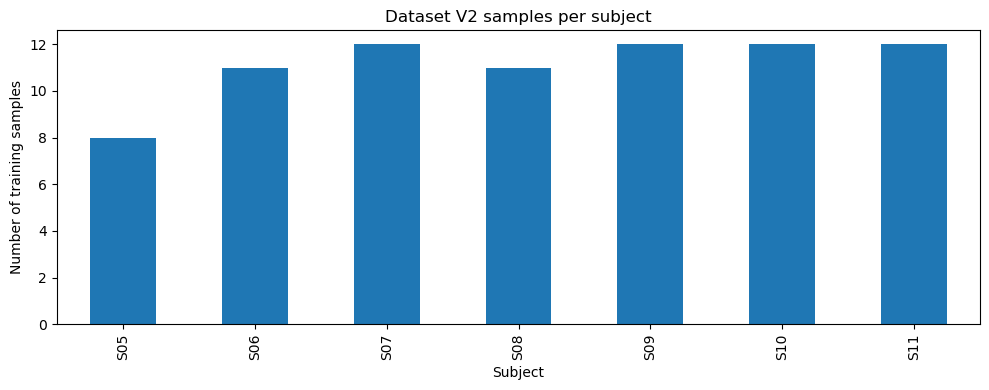

Saved: /media/data/rPPG/rPPG_Data/SHARE/PixelLabelData/dataset_v2_splits/figures/split_01_samples_per_subject.png


In [10]:
# ============================================================
# SECTION 09 — PLOT SPLIT SAMPLE COUNTS
# ============================================================

fig_dir = SPLIT_DIR / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 4))
subject_distribution.set_index("subject_id")["n_samples"].plot(kind="bar")
plt.title("Dataset V2 samples per subject")
plt.ylabel("Number of training samples")
plt.xlabel("Subject")
plt.tight_layout()
save_path = fig_dir / "split_01_samples_per_subject.png"
plt.savefig(save_path, dpi=220)
plt.show()

print("Saved:", save_path)

/tmp/ipykernel_2551786/1257762924.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=subjects, showfliers=True)


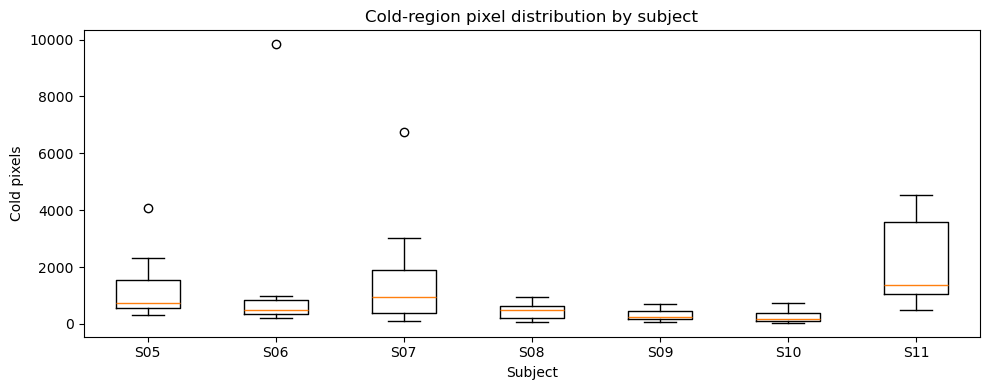

Saved: /media/data/rPPG/rPPG_Data/SHARE/PixelLabelData/dataset_v2_splits/figures/split_02_cold_pixels_boxplot_by_subject.png


In [11]:
# ============================================================
# SECTION 10 — PLOT COLD PIXEL DISTRIBUTION
# ============================================================

if "cold_pixels" in df.columns:
    plt.figure(figsize=(10, 4))
    data = [df[df["subject_id"] == sid]["cold_pixels"].values for sid in subjects]
    plt.boxplot(data, labels=subjects, showfliers=True)
    plt.title("Cold-region pixel distribution by subject")
    plt.ylabel("Cold pixels")
    plt.xlabel("Subject")
    plt.tight_layout()
    save_path = fig_dir / "split_02_cold_pixels_boxplot_by_subject.png"
    plt.savefig(save_path, dpi=220)
    plt.show()

    print("Saved:", save_path)
else:
    print("cold_pixels column not available.")

In [12]:
# ============================================================
# SECTION 11 — CHECK JSON READABILITY
# ============================================================

sample_json = SPLIT_DIR / f"fold_{subjects[0]}.json"

with open(sample_json, "r", encoding="utf-8") as f:
    sample_fold = json.load(f)

print("Sample fold:", sample_fold["fold_id"])
print("Train subjects:", sample_fold["train_subjects"])
print("Val subject:", sample_fold["val_subject"])
print("Test subject:", sample_fold["test_subject"])
print("n_train / n_val / n_test:", sample_fold["n_train"], sample_fold["n_val"], sample_fold["n_test"])

print("\nFirst train record keys:")
print(list(sample_fold["train"][0].keys()))

Sample fold: fold_S05
Train subjects: ['S07', 'S08', 'S09', 'S10', 'S11']
Val subject: S06
Test subject: S05
n_train / n_val / n_test: 59 11 8

First train record keys:
['sample_id', 'subject_id', 'doctor_group', 'repeat_id', 'prepared_image_npy', 'body_mask_path', 'cold_mask_path', 'body_pixels', 'cold_pixels', 'cold_body_ratio', 'use_for_training', 'image_path']


# Done

Use these files in the next training notebook:

```text
dataset_v2_splits/
├── fold_S05.json
├── fold_S06.json
├── fold_S07.json
├── fold_S08.json
├── fold_S09.json
├── fold_S10.json
├── fold_S11.json
└── loso_split_summary.csv
```

Next notebook:

```text
03_Train_Baseline_HierUNet_LOSO.ipynb
```